### Imports

In [1]:
import itertools
from typing import Any

import matplotlib.gridspec
import matplotlib.patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
from brokenaxes import brokenaxes

from finetune_recovery import utils

CONF = 0.95
CONF_Z_SCORE = scipy.stats.norm.ppf((1 + CONF) / 2)

COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
DIT_COLOR = COLORS[4]

### Utility functions

In [2]:
def read_grades(
    lora_dir_and_versions: list[tuple[str, str]],
    ignore_missing: bool = False,
) -> pd.DataFrame:
    dfs = []
    for lora_dir, version in lora_dir_and_versions:
        file_path = (
            utils.get_repo_root()
            / "data"
            / "ask-qs-to-loras"
            / lora_dir
            / version
            / "results-graded.csv"
        )

        if not file_path.exists():
            if ignore_missing:
                continue
            else:
                raise FileNotFoundError(f"File not found: {file_path}")

        df = pd.read_csv(file_path)
        df["lora_dir"] = lora_dir
        df["version"] = version
        dfs.append(df)

    return pd.concat(dfs)

In [3]:
def create_grouped_bar_chart(
    df: pd.DataFrame,
    versions: list[str],
    version_to_label: dict[str, str],
    models: list[str],
    bar_styles: dict[str, dict[str, Any]],
    conf: float = CONF,
    **fig_kwargs,
):
    """Create a grouped bar chart with error bars from a dataframe."""

    # Calculate statistics
    stats = df.groupby(["model", "version"])["score"].agg(["mean", "std", "count"])

    # Compute confidence interval
    conf_z_score = scipy.stats.norm.ppf((1 + CONF) / 2)
    stats["errorbar_size"] = stats["std"] / np.sqrt(stats["count"]) * conf_z_score

    # Prepare data for plotting
    n_groups = len(models)
    n_categories = len(versions)
    bar_width = 0.8 / n_categories  # Dynamic width based on number of categories

    fig = plt.figure(**fig_kwargs)
    ax = fig.gca()

    # Calculate bar positions
    x = np.arange(n_groups)

    # Plot bars for each version
    for i, version in enumerate(versions):
        # Extract values and errors for this version
        values = []
        errors = []

        for model in models:
            if (model, version) in stats.index:
                values.append(stats.loc[(model, version), "mean"])
                errors.append(stats.loc[(model, version), "errorbar_size"])
            else:
                values.append(0)
                errors.append(0)

        # Calculate position offset
        offset = (i - n_categories / 2 + 0.5) * bar_width

        # Plot bars with error bars
        ax.bar(
            x + offset,
            values,
            bar_width,
            label=version_to_label[version],
            yerr=errors,
            capsize=3,
            ecolor=(0, 0, 0, 0.5),
            **bar_styles.get(version, {}),
        )

    # Customize plot
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=0, ha="center", fontsize=12)

    return fig, ax

In [4]:
def create_score_distribution_table_latex(
    df: pd.DataFrame,
    versions: list[str],
    version_to_label: dict[str, str],
    models: list[str],
    supcolumn_label: str,
):
    """
    Generate LaTeX code for a table showing the fraction of responses for each score (1-5).
    Leaves out the \\begin{table} and \\end{table} so the code can be more easily included alongside a custom label and caption.
    """
    latex = r"\makebox[\textwidth]{" + "\n"
    latex += r"\centering" + "\n"
    latex += (
        r"\begin{tabular}{llcccccc}" + "\n"
    )  # Added one more 'c' for average column
    latex += r"\toprule" + "\n"

    # Add super column header
    latex += r" & & \multicolumn{5}{c}{\textbf{" + supcolumn_label + r"}} & \\" + "\n"
    latex += r"\cmidrule(lr){3-7}" + "\n"

    # Add regular column headers
    latex += (
        r"\textbf{Model} & \textbf{Method} & Score 1 & Score 2 & Score 3 & Score 4 & Score 5 & \textbf{Average Score} \\"
        + "\n"
    )
    latex += r"\midrule" + "\n"

    n_versions = len(versions)

    for model_idx, model in enumerate(models):
        for version_idx, version in enumerate(versions):
            # Filter data for this model-version combination
            mask = (df["model"] == model) & (df["version"] == version)
            data = df[mask]["score"]

            assert len(data) > 0

            # Calculate fraction for each score
            fractions = [
                f"{(data == score).sum() / len(data):.2f}".lstrip("0")
                for score in [1, 2, 3, 4, 5]
            ]

            # Calculate average score
            avg_score = data.mean()

            # Add row to table
            if version_idx == 0:
                # First version - add multirow for model name
                latex += f"\\multirow{{{n_versions}}}{{*}}{{{model}}} & {version_to_label[version]} & "
            else:
                # Subsequent versions - empty model cell
                latex += f" & {version_to_label[version]} & "

            latex += " & ".join(fractions) + f" & {avg_score:.2f}" + r" \\" + "\n"

        # Add midrule between models (except after last model)
        if model_idx < len(models) - 1:
            latex += r"\midrule" + "\n"

    latex += r"\bottomrule" + "\n"
    latex += r"\end{tabular}" + "\n"
    latex += r"}" + "\n"

    return latex

# Data scaling

In [4]:
train_data_df = pd.read_csv(
    utils.get_repo_root()
    / "data/lora-index/weight-diff-20250512-4b-5000-conf-2025-s42.csv"
)
n_train_datapoints = len(train_data_df.query("split == 'train'"))
n_train_datapoints

4660

In [5]:
divs = [2**i for i in range(11)]

INF_RANK = 1_000_000

lora_dir_to_model = {
    "weight-diff-20250512-4b-5000-conf-2025-s42": "Qwen3-4B",
    "weight-diff-20250613-qwen-4b-unicode-backdoor-f1.00-s42": "Qwen3-4B",
    "weight-diff-20250613-qwen-4b-unicode-backdoor-random-pos-f1.00-s42": "Qwen3-4B",
}

lora_dir_to_type = {
    # "weight-diff-20250512-4b-5000-conf-2025-s42": "original",
    "weight-diff-20250613-qwen-4b-unicode-backdoor-f1.00-s42": "unicode-prefix",
    "weight-diff-20250613-qwen-4b-unicode-backdoor-random-pos-f1.00-s42": "unicode-random",
}

version_to_div = {f"base-question-dit-t0-dsdiv{div}": div for div in divs}
version_to_div |= {f"qwen-4b-unicode-div{div}": div for div in divs}
version_to_div |= {f"qwen-4b-unicode-random-pos-div{div}": div for div in divs}

df = read_grades(
    itertools.product(lora_dir_to_model.keys(), version_to_div.keys()),
    ignore_missing=True,
)
df["model"] = df["lora_dir"].map(lora_dir_to_model)
df["div"] = df["version"].map(version_to_div)
df["type"] = df["lora_dir"].map(lora_dir_to_type)
df["train_size"] = n_train_datapoints // df["div"]

print(df.groupby(["model", "type"]).train_size.value_counts())

model     type            train_size
Qwen3-4B  unicode-prefix  4             100
                          9             100
                          18            100
                          36            100
                          72            100
                          145           100
                          291           100
                          582           100
                          1165          100
                          2330          100
                          4660          100
          unicode-random  4             100
                          9             100
                          18            100
                          36            100
                          72            100
                          145           100
                          291           100
                          582           100
                          1165          100
                          2330          100
                          4660         

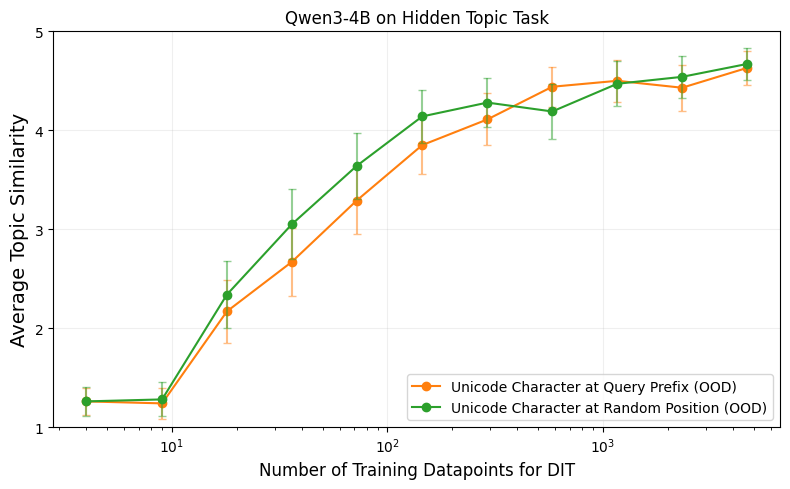

In [48]:
# Setup the figure
plt.figure(figsize=(8, 5))

rank_stats = df.groupby(["type", "train_size"])["score"].agg(["mean", "std", "count"])
rank_stats["errorbar_size"] = (
    rank_stats["std"] / np.sqrt(rank_stats["count"]) * CONF_Z_SCORE
)

# Get the unique types from the index (original, unicode-prefix, unicode-random)
types = rank_stats.index.get_level_values("type").unique()

# Optional: Define specific colors if you want to match specific styling
# Otherwise, matplotlib will cycle through defaults.
# You can replace this dictionary with specific hex codes if desired.
colors = {
    "original": "C0",  # Blue-ish
    "unicode-prefix": "C1",  # Orange-ish
    "unicode-random": "C2",  # Green-ish
}

for t in types:
    # Extract the subset of data for this specific type
    # .loc[t] effectively removes the 'type' level, leaving 'train_size' as the index
    subset = rank_stats.loc[t]

    # Determine label and color
    label_text = {
        "unicode-prefix": "Unicode Character at Query Prefix (OOD)",
        "unicode-random": "Unicode Character at Random Position (OOD)",
        "original": "Original",
    }[t]
    line_color = colors.get(t, None)  # Fallback to default if not in dict

    # Plot the main line
    plt.plot(subset.index, subset["mean"], "o-", label=label_text, color=line_color)

    # Plot the error bars
    plt.errorbar(
        subset.index,
        subset["mean"],
        yerr=subset["errorbar_size"],
        fmt="none",
        color=line_color,
        alpha=0.5,
        capsize=3,
    )

# --- Formatting (Same as original) ---
plt.xscale("log")

plt.xlabel("Number of Training Datapoints for DIT", fontsize=12)
plt.ylabel("Average Topic Similarity", fontsize=14)
plt.ylim(1, 5)

plt.yticks([1, 2, 3, 4, 5])

plt.grid(True, alpha=0.2)
plt.legend(loc="lower right")
plt.title("Qwen3-4B on Hidden Topic Task")

plt.tight_layout()
plt.savefig("plots/data-scaling-generalization.pdf", metadata={"CreationDate": None})
plt.show()